# Analisi degli esperimenti

Nessun numero in questo notebook e' scritto a mano: tutto viene da `results/experiments.csv`, prodotto da `python src/run_experiments.py` secondo la griglia dichiarata in `config.yaml`. Per aggiungere un dataset, cambiare repeats o griglia dei modelli si modifica `config.yaml` e si rilancia il runner - questo notebook si aggiorna semplicemente ri-eseguendolo.

`status` per dataset (colonna in config.yaml):
- **closed**: KIMORE ex5, gia' validato a fondo in sessioni precedenti (nessun segnale, vedi MODEL_CARD) - qui girato con lo stesso rigore di tutto il resto (repeats=20) solo per riconfermare il numero, non per riaprire il caso.
- **indicative**: UI-PRMD, segnale forte ma non validabile del tutto (nessun ID soggetto nel file pubblico, target di regressione circolare) - trattato con cautela.
- **active**: REHAB24-6, la linea di lavoro attuale, con split corretto per soggetto. Tre famiglie di feature confrontate per ogni esercizio: base (PCA traiettoria posizione), dynamics (PCA posizione+velocita'+accelerazione) e anatomical (angoli articolari con nome).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)

df = pd.read_csv("../results/experiments.csv")
print(f"{df.shape[0]} righe (dataset x modello x repeat x fold)")
meta_cols = ["dataset", "task", "n_samples", "n_features", "grouped", "status"]
print(df[meta_cols].drop_duplicates().to_string(index=False))

9624 righe (dataset x modello x repeat x fold)
                              dataset           task  n_samples  n_features  grouped     status
                kimore_ex5_regression     regression         75          37    False     closed
            kimore_ex5_classification classification         75          59    False     closed
     ui_prmd_deepsquat_classification classification        180          20    False indicative
         ui_prmd_deepsquat_regression     regression        180          20    False indicative
                          rehab24_ex1 classification         88          20     True     active
                rehab24_ex1_ungrouped classification         88          20    False     active
                          rehab24_ex2 classification        109          20     True     active
                          rehab24_ex3 classification        107          20     True     active
                          rehab24_ex4 classification        116          20     True     

## Metrica primaria e intervallo di confidenza per bootstrap

Media e std tra i fold gia' danno un'idea della variabilita', ma per un confronto piu' onesto tra modelli si aggiunge un intervallo di confidenza al 95% via bootstrap sui fold (resampling con reinserimento delle 50 - o meno, se repeats e' stato ridotto - stime di fold), che non assume normalita' e riflette meglio quanto ci si possa fidare della media con questi campioni piccoli.

In [2]:
df["primary_metric"] = df["auc"].where(df["task"] == "classification", df["spearman"])

def bootstrap_ci(values, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    values = values.dropna().values
    if len(values) < 2:
        return np.nan, np.nan
    boots = [rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_boot)]
    return np.percentile(boots, 2.5), np.percentile(boots, 97.5)

rows = []
for (dataset, model), g in df.groupby(["dataset", "model"]):
    lo, hi = bootstrap_ci(g["primary_metric"])
    rows.append({"dataset": dataset, "model": model, "mean": g["primary_metric"].mean(),
                 "std": g["primary_metric"].std(), "ci_lo": lo, "ci_hi": hi, "n_folds": g.shape[0]})
summary = pd.DataFrame(rows).sort_values(["dataset", "mean"], ascending=[True, False])
print(summary.to_string(index=False, float_format="%.3f"))

                              dataset  model   mean   std  ci_lo  ci_hi  n_folds
            kimore_ex5_classification     rf  0.623 0.123  0.598  0.647      100
            kimore_ex5_classification logreg  0.616 0.131  0.590  0.641      100
            kimore_ex5_classification    mlp  0.577 0.139  0.550  0.604      100
            kimore_ex5_classification  dummy  0.525 0.129  0.500  0.550      100
                kimore_ex5_regression    mlp  0.142 0.225  0.099  0.186      100
                kimore_ex5_regression  ridge  0.098 0.243  0.051  0.145      100
                kimore_ex5_regression     rf -0.053 0.242 -0.101 -0.006      100
                kimore_ex5_regression  dummy    NaN   NaN    NaN    NaN      100
                          rehab24_ex1    mlp  0.902 0.100  0.882  0.921      100
                          rehab24_ex1 logreg  0.894 0.142  0.866  0.921      100
                          rehab24_ex1     rf  0.683 0.216  0.637  0.723      100
                          re

## Grafico: metrica primaria per dataset, tutti i modelli (con IC 95% bootstrap)

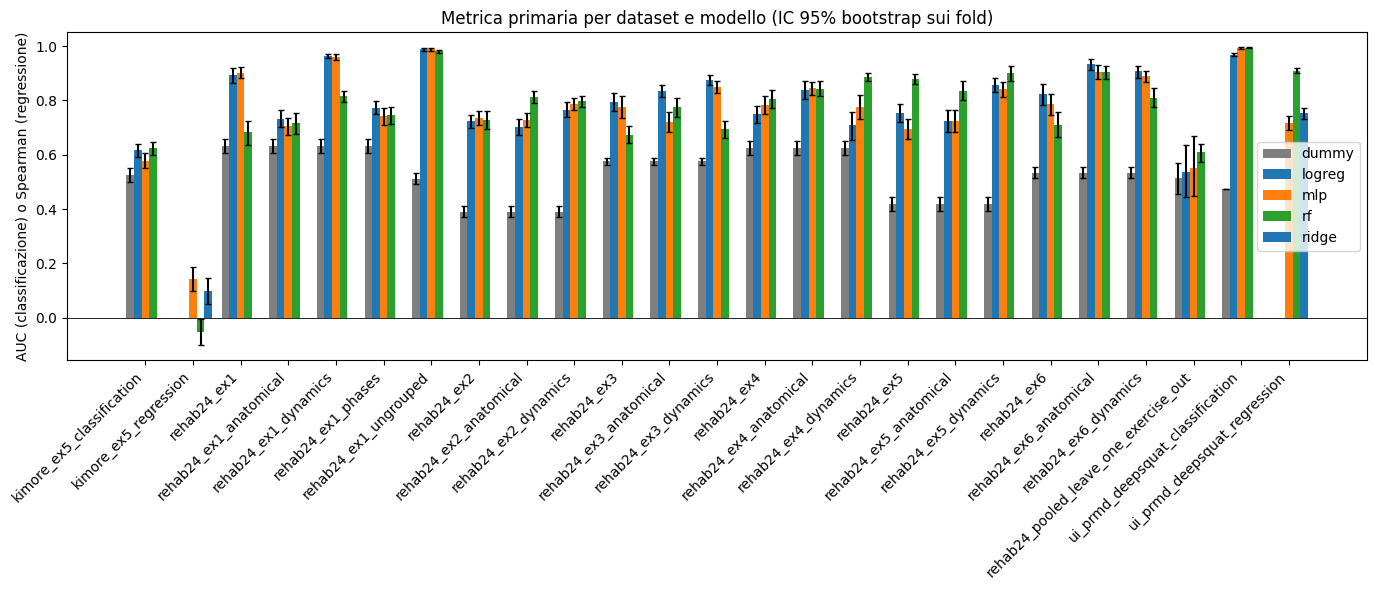

In [3]:
datasets = summary["dataset"].unique()
models = sorted(df["model"].unique())
colors = {"dummy": "tab:gray", "ridge": "tab:blue", "logreg": "tab:blue",
          "rf": "tab:green", "mlp": "tab:orange"}

fig, ax = plt.subplots(figsize=(14, 6))
width = 0.8 / len(models)
x = np.arange(len(datasets))

for i, model in enumerate(models):
    means, err_lo, err_hi = [], [], []
    for d in datasets:
        row = summary[(summary["dataset"] == d) & (summary["model"] == model)]
        if len(row):
            m, lo, hi = row["mean"].values[0], row["ci_lo"].values[0], row["ci_hi"].values[0]
        else:
            m, lo, hi = np.nan, np.nan, np.nan
        means.append(m)
        err_lo.append(m - lo if not np.isnan(m) else 0)
        err_hi.append(hi - m if not np.isnan(m) else 0)
    ax.bar(x + i * width, means, width, yerr=[err_lo, err_hi], label=model,
           color=colors.get(model, "tab:purple"), capsize=2)

ax.axhline(0, color="black", linewidth=0.6)
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(datasets, rotation=45, ha="right")
ax.set_ylabel("AUC (classificazione) o Spearman (regressione)")
ax.set_title("Metrica primaria per dataset e modello (IC 95% bootstrap sui fold)")
ax.legend()
plt.tight_layout()
plt.show()

## Scelta metodologica: perche' il raggruppamento per soggetto conta

`rehab24_ex1` e `rehab24_ex1_ungrouped` usano identiche feature e identico modello: l'unica differenza e' se la nested CV rispetta i confini di soggetto (`groups: subject`) o tratta ogni ripetizione come indipendente (`groups: null`, split per riga, rischio di leakage).

              dataset  model  mean   std  ci_lo  ci_hi  n_folds
          rehab24_ex1    mlp 0.902 0.100  0.882  0.921      100
          rehab24_ex1 logreg 0.894 0.142  0.866  0.921      100
          rehab24_ex1     rf 0.683 0.216  0.637  0.723      100
          rehab24_ex1  dummy 0.632 0.130  0.605  0.658      100
rehab24_ex1_ungrouped    mlp 0.988 0.025  0.982  0.992      100
rehab24_ex1_ungrouped logreg 0.987 0.022  0.983  0.992      100
rehab24_ex1_ungrouped     rf 0.982 0.030  0.975  0.987      100
rehab24_ex1_ungrouped  dummy 0.511 0.102  0.492  0.532      100


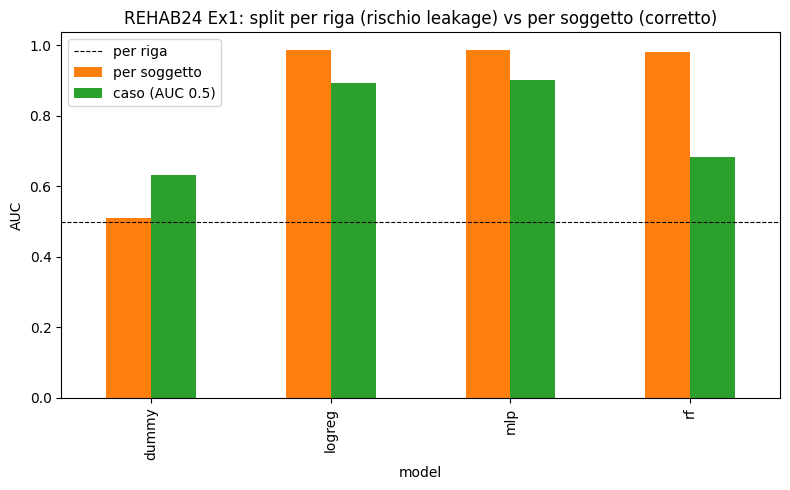

In [4]:
compare = summary[summary["dataset"].isin(["rehab24_ex1", "rehab24_ex1_ungrouped"])]
print(compare.to_string(index=False, float_format="%.3f"))

fig, ax = plt.subplots(figsize=(8, 5))
sub = compare.pivot(index="model", columns="dataset", values="mean")
sub = sub.reindex(columns=["rehab24_ex1_ungrouped", "rehab24_ex1"])
sub.plot(kind="bar", ax=ax, color=["tab:orange", "tab:green"])
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
ax.set_ylabel("AUC")
ax.set_title("REHAB24 Ex1: split per riga (rischio leakage) vs per soggetto (corretto)")
ax.legend(["per riga", "per soggetto", "caso (AUC 0.5)"])
plt.tight_layout()
plt.show()

## Su quanti esercizi REHAB24 il segnale regge?

Tutti e sei con split corretto per soggetto, stesse feature (trajectory-PCA), stessi modelli.

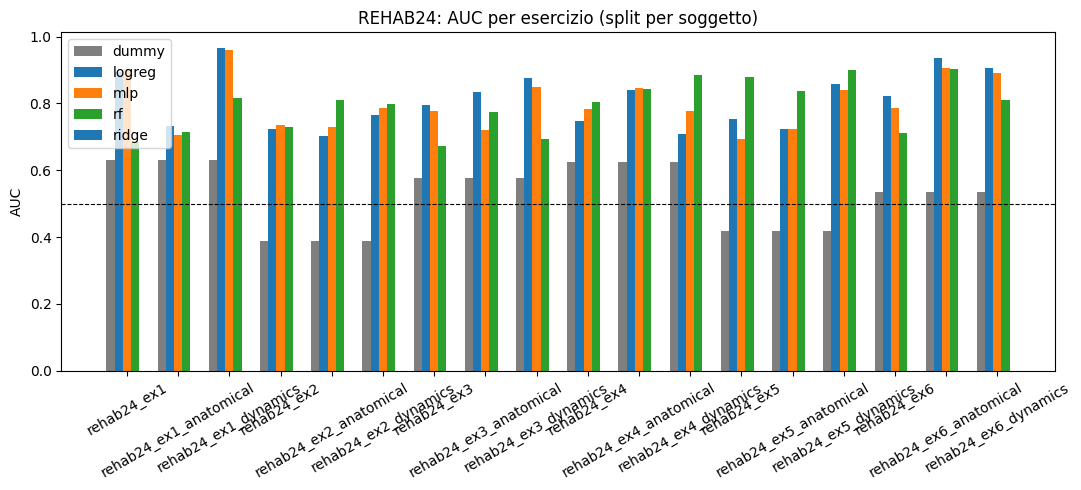

In [5]:
rehab_cols = [d for d in datasets if d.startswith("rehab24_ex") and "ungrouped" not in d and "phases" not in d]
rehab_summary = summary[summary["dataset"].isin(rehab_cols)]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(rehab_cols))
for i, model in enumerate(models):
    means = [rehab_summary[(rehab_summary["dataset"] == d) & (rehab_summary["model"] == model)]["mean"].values
             for d in rehab_cols]
    means = [m[0] if len(m) else np.nan for m in means]
    ax.bar(x + i * width, means, width, label=model, color=colors.get(model, "tab:purple"))

ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(rehab_cols, rotation=30)
ax.set_ylabel("AUC")
ax.set_title("REHAB24: AUC per esercizio (split per soggetto)")
ax.legend()
plt.tight_layout()
plt.show()

## Le fasi del movimento aiutano? (idea da Temporal Parsing Transformer / FineParser)

`rehab24_ex1_phases` divide ogni ripetizione in tre terzi temporali (inizio/meta/fine) e fa la PCA separatamente su ciascuno, invece che sull'intera traiettoria. Non e' un parser appreso come nei paper, ma la stessa intuizione tenuta semplice: l'errore potrebbe concentrarsi in una fase specifica piuttosto che nell'intero movimento.

In [6]:
compare_phases = summary[summary["dataset"].isin(["rehab24_ex1", "rehab24_ex1_phases"])]
print(compare_phases.to_string(index=False, float_format="%.3f"))
print("\nSe 'rehab24_ex1_phases' non supera 'rehab24_ex1', la segmentazione per fasi non")
print("aggiunge segnale qui (puo' comunque tornare utile in Fase 4 per localizzare l'errore,")
print("anche a parita' di accuratezza complessiva).")

           dataset  model  mean   std  ci_lo  ci_hi  n_folds
       rehab24_ex1    mlp 0.902 0.100  0.882  0.921      100
       rehab24_ex1 logreg 0.894 0.142  0.866  0.921      100
       rehab24_ex1     rf 0.683 0.216  0.637  0.723      100
       rehab24_ex1  dummy 0.632 0.130  0.605  0.658      100
rehab24_ex1_phases logreg 0.772 0.124  0.748  0.797      100
rehab24_ex1_phases     rf 0.746 0.156  0.714  0.775      100
rehab24_ex1_phases    mlp 0.741 0.166  0.708  0.773      100
rehab24_ex1_phases  dummy 0.632 0.130  0.605  0.658      100

Se 'rehab24_ex1_phases' non supera 'rehab24_ex1', la segmentazione per fasi non
aggiunge segnale qui (puo' comunque tornare utile in Fase 4 per localizzare l'errore,
anche a parita' di accuratezza complessiva).


## Quale famiglia di feature vince, esercizio per esercizio?

Domanda centrale di questo sweep: base (PCA sulla sola posizione), dynamics (PCA su posizione+velocita'+accelerazione, motivata dalla letteratura su smoothness/jerk) e anatomical (angoli articolari con nome, motivata dalla tesi di interpretabilita' del progetto) non sono alternative teoriche - ora ci sono 6 esercizi x 3 famiglie x 4 modelli di dati per dire quale vince davvero, e dove.

exercise     family best_model  mean  ci_lo  ci_hi  dummy  uplift_vs_dummy
     ex1       base        mlp 0.902  0.882  0.921  0.632            0.270
     ex1   dynamics     logreg 0.964  0.957  0.972  0.632            0.333
     ex1 anatomical     logreg 0.733  0.703  0.763  0.632            0.101
     ex2       base        mlp 0.737  0.710  0.762  0.388            0.348
     ex2   dynamics         rf 0.797  0.777  0.817  0.388            0.409
     ex2 anatomical         rf 0.811  0.789  0.835  0.388            0.423
     ex3       base     logreg 0.795  0.761  0.829  0.576            0.219
     ex3   dynamics     logreg 0.875  0.856  0.894  0.576            0.299
     ex3 anatomical     logreg 0.835  0.812  0.858  0.576            0.259
     ex4       base         rf 0.806  0.772  0.837  0.625            0.181
     ex4   dynamics         rf 0.885  0.871  0.900  0.625            0.260
     ex4 anatomical        mlp 0.845  0.820  0.866  0.625            0.220
     ex5       base      

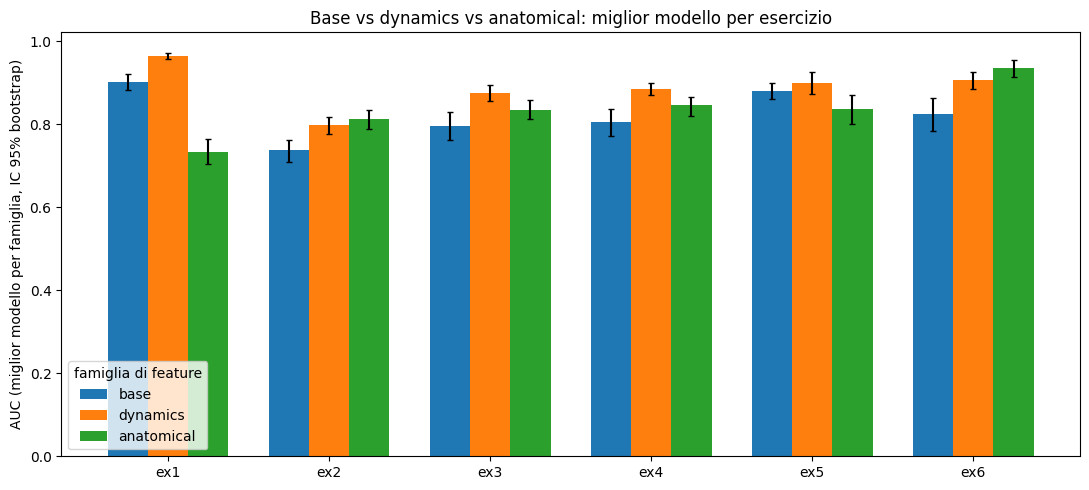

In [7]:
families = {"base": "", "dynamics": "_dynamics", "anatomical": "_anatomical"}
exercises = [f"ex{i}" for i in range(1, 7)]

best_rows = []
for ex in exercises:
    for fam, suffix in families.items():
        name = f"rehab24_{ex}{suffix}"
        sub = summary[summary["dataset"] == name]
        sub = sub[sub["model"] != "dummy"]
        if sub.empty:
            continue
        best = sub.loc[sub["mean"].idxmax()]
        dummy_row = summary[(summary["dataset"] == name) & (summary["model"] == "dummy")]
        dummy_val = dummy_row["mean"].values[0] if len(dummy_row) else np.nan
        best_rows.append({"exercise": ex, "family": fam, "best_model": best["model"],
                           "mean": best["mean"], "ci_lo": best["ci_lo"], "ci_hi": best["ci_hi"],
                           "dummy": dummy_val, "uplift_vs_dummy": best["mean"] - dummy_val})

best_df = pd.DataFrame(best_rows)
print(best_df.to_string(index=False, float_format="%.3f"))

winner = best_df.loc[best_df.groupby("exercise")["mean"].idxmax()]
print("\nFamiglia vincente per esercizio (miglior modello, per AUC media):")
print(winner[["exercise", "family", "best_model", "mean"]].to_string(index=False, float_format="%.3f"))
print(f"\nConteggio vittorie: {winner['family'].value_counts().to_dict()}")

fig, ax = plt.subplots(figsize=(11, 5))
fam_colors = {"base": "tab:blue", "dynamics": "tab:orange", "anatomical": "tab:green"}
x = np.arange(len(exercises))
w = 0.25
for i, fam in enumerate(families):
    sub = best_df[best_df["family"] == fam].set_index("exercise").reindex(exercises)
    err_lo = (sub["mean"] - sub["ci_lo"]).values
    err_hi = (sub["ci_hi"] - sub["mean"]).values
    ax.bar(x + (i - 1) * w, sub["mean"].values, w, yerr=[err_lo, err_hi], capsize=2,
           label=fam, color=fam_colors[fam])
ax.set_xticks(x)
ax.set_xticklabels(exercises)
ax.set_ylabel("AUC (miglior modello per famiglia, IC 95% bootstrap)")
ax.set_title("Base vs dynamics vs anatomical: miglior modello per esercizio")
ax.legend(title="famiglia di feature")
plt.tight_layout()
plt.show()

## Il segnale sopravvive al cambio di esercizio? (proxy Pilastro 3)

`rehab24_pooled_leave_one_exercise_out` allena su 5 esercizi e testa sul sesto, mai visto, usando le feature anatomiche (le uniche condivise concettualmente tra esercizi diversi - un angolo di ginocchio e' lo stesso angolo in uno squat o in un affondo, una componente PCA no). Con solo 6 gruppi e split deterministico, repeats=1 e' corretto (non una scorciatoia): rifare lo split non cambierebbe nulla.

                              dataset  model  mean   std  ci_lo  ci_hi  n_folds
rehab24_pooled_leave_one_exercise_out     rf 0.608 0.046  0.574  0.638        6
rehab24_pooled_leave_one_exercise_out    mlp 0.550 0.157  0.446  0.670        6
rehab24_pooled_leave_one_exercise_out logreg 0.535 0.133  0.444  0.637        6
rehab24_pooled_leave_one_exercise_out  dummy 0.515 0.079  0.456  0.570        6


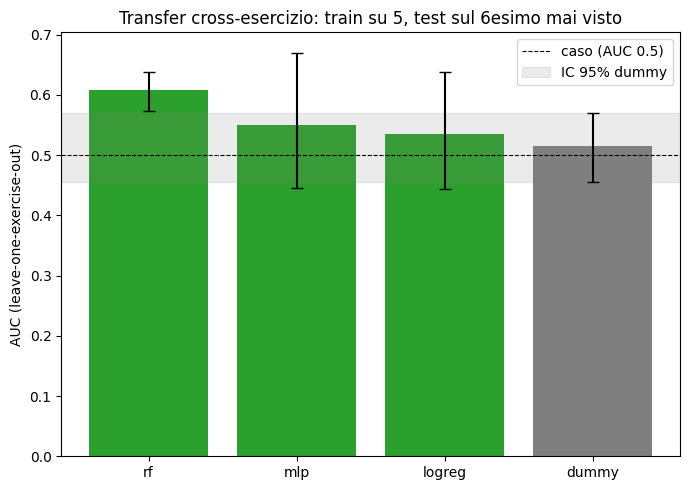


Solo il modello il cui IC 95% non si sovrappone a quello del dummy batte il caso in
modo difendibile con soli 6 fold. Con questo campione (6 esercizi), un IC largo e'
atteso: onestamente, questo e' un segnale di transfer modesto, non forte - una prima
prova che l'informazione utile non e' del tutto specifica per esercizio, non una
dimostrazione di transfer robusto verso il Pilates.


In [8]:
loeo = summary[summary["dataset"] == "rehab24_pooled_leave_one_exercise_out"].sort_values("mean", ascending=False)
print(loeo.to_string(index=False, float_format="%.3f"))

dummy_ci = loeo[loeo["model"] == "dummy"][["ci_lo", "ci_hi"]].values[0]
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(loeo["model"], loeo["mean"],
       yerr=[loeo["mean"] - loeo["ci_lo"], loeo["ci_hi"] - loeo["mean"]],
       capsize=4, color=["tab:green" if m != "dummy" else "tab:gray" for m in loeo["model"]])
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="caso (AUC 0.5)")
ax.axhspan(dummy_ci[0], dummy_ci[1], color="tab:gray", alpha=0.15, label="IC 95% dummy")
ax.set_ylabel("AUC (leave-one-exercise-out)")
ax.set_title("Transfer cross-esercizio: train su 5, test sul 6esimo mai visto")
ax.legend()
plt.tight_layout()
plt.show()

print("\nSolo il modello il cui IC 95% non si sovrappone a quello del dummy batte il caso in")
print("modo difendibile con soli 6 fold. Con questo campione (6 esercizi), un IC largo e'")
print("atteso: onestamente, questo e' un segnale di transfer modesto, non forte - una prima")
print("prova che l'informazione utile non e' del tutto specifica per esercizio, non una")
print("dimostrazione di transfer robusto verso il Pilates.")

## Tabella completa (tutti i dataset, tutti i modelli)

In [9]:
print(summary.to_string(index=False, float_format="%.3f"))

                              dataset  model   mean   std  ci_lo  ci_hi  n_folds
            kimore_ex5_classification     rf  0.623 0.123  0.598  0.647      100
            kimore_ex5_classification logreg  0.616 0.131  0.590  0.641      100
            kimore_ex5_classification    mlp  0.577 0.139  0.550  0.604      100
            kimore_ex5_classification  dummy  0.525 0.129  0.500  0.550      100
                kimore_ex5_regression    mlp  0.142 0.225  0.099  0.186      100
                kimore_ex5_regression  ridge  0.098 0.243  0.051  0.145      100
                kimore_ex5_regression     rf -0.053 0.242 -0.101 -0.006      100
                kimore_ex5_regression  dummy    NaN   NaN    NaN    NaN      100
                          rehab24_ex1    mlp  0.902 0.100  0.882  0.921      100
                          rehab24_ex1 logreg  0.894 0.142  0.866  0.921      100
                          rehab24_ex1     rf  0.683 0.216  0.637  0.723      100
                          re

## Prossimi passi onesti

1. **KIMORE ex5**: chiuso (nessun segnale in nessuna formulazione, 9+ strategie indipendenti provate). Non riaprire senza un nuovo dataset o target.
2. **UI-PRMD**: indicativo, non conclusivo. Per validarlo servirebbe il dataset raw con ID soggetto (es. il mirror Kaggle, richiede account).
3. **REHAB24-6, quale famiglia di feature usare**: dai numeri sopra, `dynamics` (posizione+velocita'+accelerazione) vince su 4 esercizi su 6 (ex1, ex3, ex4, ex5) - lo smoothness/jerk del movimento porta piu' segnale discriminativo puro di quanto previsto. `anatomical` vince sui restanti 2 (ex2, ex6), nonostante il controllo univariato (sessione precedente) mostrasse il segnale piu' ampio e forte di ogni famiglia su tutti gli esercizi - segno che un segnale univariato forte non si traduce automaticamente nel miglior modello multivariato con questi campioni piccoli. Questo non toglie valore ad `anatomical`: resta l'unica famiglia con feature nominabili (angolo del ginocchio, valgismo, asimmetria) e quindi l'unica adatta al feedback per-articolazione della Fase 4 e all'unico test di transfer cross-esercizio possibile oggi (punto 4).
4. **Transfer cross-esercizio (proxy Pilastro 3)**: segnale presente ma modesto (rf sopra il dummy con IC non sovrapposti, logreg/mlp entro l'incertezza del caso) - onestamente un primo indizio che l'informazione su "esecuzione corretta" non e' del tutto specifica per esercizio, non una prova di transfer robusto verso il Pilates reale.
5. **Prossimo lavoro**: (a) SHAP sulle feature anatomiche del/dei modelli vincenti per esercizio, per capire quali angoli guidano davvero la classificazione e se coincidono con l'intuizione clinica; (b) provare feature che uniscano dynamics + anatomical (velocita'/accelerazione degli angoli con nome, non delle componenti PCA) per unire il potere discriminativo di dynamics all'interpretabilita' di anatomical; (c) se si vuole affrontare la Fase 3 del playbook, confronto con una baseline deep (ST-GCN); (d) estendere la segmentazione per fase (oggi solo su Ex1, e senza guadagno) alle altre feature/esercizi per il feedback per-fase della Fase 4.